# 02 · PointMaze Closed-Loop Evaluation (Paper-Aligned)

This notebook produces the PointMaze deployment results reported in the paper:
- Figure 5 (`sample_efficiency_pointmaze_closedloop.pdf`)
- Closed-loop claims in the abstract and Section 5

**Protocol parity with paper:**
1. Official `PointMaze_UMaze-v3` environment
2. Multi-seed rollouts with fixed episode budget per trial
3. Per-fraction sample-efficiency checkpoints (1%, 2.15%, 4.64%, 10%, 21.54%, 46.42%, 100%)
4. Original + alternate seed-family pooling to reduce variance

> Kernel requirement: use `.venv312` (Python 3.12 + MuJoCo + gymnasium-robotics).

In [18]:
import collections
import io
import os
import time
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import torch.nn.functional as F
import gymnasium as gym
from gymnasium import spaces
from tqdm.auto import tqdm
from IPython.display import Image, display

PM_OBS_WINDOW = 2
PM_STATE_DIM = 8
GOAL_POS = np.array([0.75, 0.75], dtype=np.float32)

pm_device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

checkpoint_dir = Path(os.getcwd()) / "checkpoints"

def _pick_checkpoint(prefix: str):
    continued = sorted(checkpoint_dir.glob(f"{prefix}_*continued.pt"))
    if continued:
        return continued[-1]
    best = sorted(checkpoint_dir.glob(f"{prefix}_*best.pt"))
    if best:
        return best[-1]
    raise FileNotFoundError(f"No checkpoint found for prefix: {prefix}")

liquid_pm_ckpt = _pick_checkpoint("liquid_jepa_pointmaze_umaze_fair_halfparam_deterministic_clip")
diffusion_pm_ckpt = _pick_checkpoint("diffusion_jepa_pointmaze_umaze_fair_halfparam_deterministic_clip")

print(f"Device: {pm_device}")
print(f"Liquid checkpoint: {liquid_pm_ckpt.name}")
print(f"Diffusion checkpoint: {diffusion_pm_ckpt.name}")

Device: mps
Liquid checkpoint: liquid_jepa_pointmaze_umaze_fair_halfparam_deterministic_clip_240epochs_continued.pt
Diffusion checkpoint: diffusion_jepa_pointmaze_umaze_fair_halfparam_deterministic_clip_240epochs_continued.pt


In [19]:
liquid_pm_state = torch.load(liquid_pm_ckpt, map_location=pm_device, weights_only=False)
diffusion_pm_state = torch.load(diffusion_pm_ckpt, map_location=pm_device, weights_only=False)

# Liquid tensors
liq_state_proj_w = liquid_pm_state["backbone.state_proj.weight"]
liq_state_proj_b = liquid_pm_state["backbone.state_proj.bias"]
liq_context_proj_w = liquid_pm_state["backbone.context_proj.weight"]
liq_context_proj_b = liquid_pm_state["backbone.context_proj.bias"]
liq_head_context_w = liquid_pm_state["context_proj.weight"]
liq_head_context_b = liquid_pm_state["context_proj.bias"]
liq_mdn_logits_w = liquid_pm_state["mdn_logits.weight"]
liq_mdn_logits_b = liquid_pm_state["mdn_logits.bias"]
liq_mdn_mu_w = liquid_pm_state["mdn_mu.weight"]
liq_mdn_mu_b = liquid_pm_state["mdn_mu.bias"]

# Diffusion tensors
diff_state_proj_w = diffusion_pm_state["backbone.state_proj.weight"]
diff_state_proj_b = diffusion_pm_state["backbone.state_proj.bias"]
diff_context_proj_w = diffusion_pm_state["backbone.context_proj.weight"]
diff_context_proj_b = diffusion_pm_state["backbone.context_proj.bias"]
diff_head_context_w = diffusion_pm_state["context_proj.weight"]
diff_head_context_b = diffusion_pm_state["context_proj.bias"]
diff_mdn_logits_w = diffusion_pm_state["mdn_logits.weight"]
diff_mdn_logits_b = diffusion_pm_state["mdn_logits.bias"]
diff_mdn_mu_w = diffusion_pm_state["mdn_mu.weight"]
diff_mdn_mu_b = diffusion_pm_state["mdn_mu.bias"]

# Policy sampling settings
# Use sampling for liquid by default (user request), deterministic for diffusion baseline.
LIQUID_POLICY_MODE = "sample"      # "sample" or "deterministic"
DIFFUSION_POLICY_MODE = "deterministic"
MDN_TEMPERATURE = 1.0
ACTION_SAMPLE_STD = 0.20  # small noise scale around selected mixture mean


def _pm_backbone_context(obs_history_np, state_proj_w, state_proj_b, backbone_context_w, backbone_context_b):
    x = torch.as_tensor(obs_history_np, dtype=torch.float32, device=pm_device).unsqueeze(0)
    tok = torch.tanh(torch.matmul(x, state_proj_w.t()) + state_proj_b)
    ctx = torch.tanh(torch.matmul(tok.mean(dim=1), backbone_context_w.t()) + backbone_context_b)
    return ctx


def _pm_action_from_context(
    ctx,
    head_context_w,
    head_context_b,
    mdn_logits_w,
    mdn_logits_b,
    mdn_mu_w,
    mdn_mu_b,
    mode="deterministic",
    temperature=1.0,
    sample_std=0.20,
):
    h = torch.tanh(torch.matmul(ctx, head_context_w.t()) + head_context_b)
    logits = torch.clamp(torch.matmul(h, mdn_logits_w.t()) + mdn_logits_b, -30.0, 30.0)
    mu = torch.matmul(h, mdn_mu_w.t()) + mdn_mu_b
    K = logits.shape[-1]
    mu = mu.view(1, K, 2)

    if mode == "sample":
        probs = torch.softmax(logits / max(1e-6, float(temperature)), dim=-1)
        k_idx = torch.multinomial(probs[0], num_samples=1).item()
        base = mu[0, k_idx]
        noise = torch.randn_like(base) * float(sample_std)
        action = base + noise
    else:
        best_k = torch.argmax(torch.log_softmax(logits, dim=-1), dim=-1)
        action = mu[0, best_k.item()]

    return action.detach().cpu().numpy()


def liquid_pointmaze_action(obs_history_np):
    ctx = _pm_backbone_context(
        obs_history_np,
        liq_state_proj_w, liq_state_proj_b,
        liq_context_proj_w, liq_context_proj_b,
    )
    return _pm_action_from_context(
        ctx,
        liq_head_context_w, liq_head_context_b,
        liq_mdn_logits_w, liq_mdn_logits_b,
        liq_mdn_mu_w, liq_mdn_mu_b,
        mode=LIQUID_POLICY_MODE,
        temperature=MDN_TEMPERATURE,
        sample_std=ACTION_SAMPLE_STD,
    )


def diffusion_pointmaze_action(obs_history_np):
    ctx = _pm_backbone_context(
        obs_history_np,
        diff_state_proj_w, diff_state_proj_b,
        diff_context_proj_w, diff_context_proj_b,
    )
    return _pm_action_from_context(
        ctx,
        diff_head_context_w, diff_head_context_b,
        diff_mdn_logits_w, diff_mdn_logits_b,
        diff_mdn_mu_w, diff_mdn_mu_b,
        mode=DIFFUSION_POLICY_MODE,
        temperature=MDN_TEMPERATURE,
        sample_std=ACTION_SAMPLE_STD,
    )


_dummy = np.zeros((PM_OBS_WINDOW, PM_STATE_DIM), dtype=np.float32)
print(f"Liquid mode: {LIQUID_POLICY_MODE}, Diffusion mode: {DIFFUSION_POLICY_MODE}")
print("Liquid action sample:", np.round(liquid_pointmaze_action(_dummy), 4))
print("Diffusion action sample:", np.round(diffusion_pointmaze_action(_dummy), 4))

Liquid mode: sample, Diffusion mode: deterministic
Liquid action sample: [0.0387 0.2582]
Diffusion action sample: [ 0.0078 -0.0077]


In [10]:
import sys
print("Python executable:", sys.executable)

try:
    import gymnasium_robotics  # noqa: F401
    pointmaze_ids = sorted([spec.id for spec in gym.envs.registry.values() if "PointMaze" in spec.id])
    print(f"PointMaze IDs registered: {len(pointmaze_ids)}")
    for env_id in pointmaze_ids[:8]:
        print(" -", env_id)
except Exception as e:
    print("gymnasium_robotics not usable in this kernel:", repr(e))

Python executable: /Users/ncorrell/Library/CloudStorage/OneDrive-UCB-O365/Desktop/random/liquidnets/.venv312/bin/python
PointMaze IDs registered: 20
 - PointMaze_Large-v3
 - PointMaze_LargeDense-v3
 - PointMaze_Large_Diverse_G-v3
 - PointMaze_Large_Diverse_GDense-v3
 - PointMaze_Large_Diverse_GR-v3
 - PointMaze_Large_Diverse_GRDense-v3
 - PointMaze_Medium-v3
 - PointMaze_MediumDense-v3


In [20]:
def make_pointmaze_env(require_official=True, render_mode=None):
    """
    Build an official Gymnasium-Robotics PointMaze env when available.
    If require_official=True and official envs are unavailable, raise an error
    instead of silently falling back.
    """
    robotics_import_error = None
    try:
        import gymnasium_robotics  # noqa: F401  # registers PointMaze env IDs
    except Exception as e:
        robotics_import_error = e

    candidates = [
        "PointMaze_UMazeDense-v3",
        "PointMaze_UMaze-v3",
        "PointMaze_MediumDense-v3",
        "PointMaze_Medium-v3",
        "PointMaze_OpenDense-v3",
        "PointMaze_Open-v3",
    ]

    for env_id in candidates:
        try:
            if render_mode is None:
                env = gym.make(env_id)
            else:
                env = gym.make(env_id, render_mode=render_mode)
            print(f"Using official env: {env_id}")
            return env, env_id
        except Exception:
            pass

    available_pointmaze = sorted([
        spec.id for spec in gym.envs.registry.values() if "PointMaze" in spec.id
    ])

    if require_official:
        details = (
            f"\nImport error: {repr(robotics_import_error)}"
            if robotics_import_error is not None
            else ""
        )
        raise RuntimeError(
            "Official PointMaze env not available in this kernel. "
            f"Found PointMaze IDs: {available_pointmaze}{details}\n"
            "Select kernel 'Python (liquidnets .venv312)' and rerun from Cell 1."
        )

    class PointMazeLiteEnv(gym.Env):
        metadata = {"render_modes": ["rgb_array"], "render_fps": 20}

        def __init__(self, max_steps=300):
            super().__init__()
            self.max_steps = max_steps
            self.observation_space = spaces.Box(low=-2.0, high=2.0, shape=(8,), dtype=np.float32)
            self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
            self.step_count = 0
            self.pos = None
            self.vel = None
            self.goal = np.array([0.75, 0.75], dtype=np.float32)

        def _obs(self):
            d = self.goal - self.pos
            return np.array([
                self.pos[0], self.pos[1],
                self.vel[0], self.vel[1],
                self.goal[0], self.goal[1],
                d[0], d[1],
            ], dtype=np.float32)

        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            self.step_count = 0
            self.pos = np.array([-0.8, -0.8], dtype=np.float32)
            self.vel = np.zeros(2, dtype=np.float32)
            return self._obs(), {"success": False}

        def _blocked(self, p):
            x, y = p
            in_left_wall = (-0.2 <= x <= -0.1) and (-0.8 <= y <= 0.4)
            in_right_wall = (0.1 <= x <= 0.2) and (-0.8 <= y <= 0.4)
            in_bottom_wall = (-0.2 <= x <= 0.2) and (-0.8 <= y <= -0.7)
            return in_left_wall or in_right_wall or in_bottom_wall

        def step(self, action):
            self.step_count += 1
            a = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)

            self.vel = 0.85 * self.vel + 0.15 * a
            new_pos = np.clip(self.pos + 0.06 * self.vel, -1.0, 1.0)

            if not self._blocked(new_pos):
                self.pos = new_pos
            else:
                self.vel *= 0.0

            dist = np.linalg.norm(self.goal - self.pos)
            reward = -float(dist)
            success = bool(dist < 0.10)
            terminated = success
            truncated = self.step_count >= self.max_steps
            return self._obs(), reward, terminated, truncated, {"success": success}

        def render(self):
            fig, ax = plt.subplots(figsize=(3.2, 3.2), dpi=80)
            ax.set_facecolor('#1a1a2e')
            fig.patch.set_facecolor('#1a1a2e')
            wall_color = '#4a5568'
            for xy, w, h in [((-0.2, -0.8), 0.1, 1.2), ((0.1, -0.8), 0.1, 1.2), ((-0.2, -0.8), 0.4, 0.1)]:
                ax.add_patch(mpatches.Rectangle(xy, w, h, linewidth=0, facecolor=wall_color))
            ax.add_patch(plt.Circle(self.goal, 0.12, color='#f6e05e', alpha=0.25, zorder=4))
            ax.add_patch(plt.Circle(self.goal, 0.06, color='#f6e05e', alpha=0.90, zorder=5))
            ax.add_patch(plt.Circle(self.pos, 0.07, color='#68d391', alpha=1.0, zorder=10))
            ax.set_xlim(-1.05, 1.05)
            ax.set_ylim(-1.05, 1.05)
            ax.set_aspect('equal')
            ax.set_xticks([])
            ax.set_yticks([])
            plt.tight_layout(pad=0.1)
            buf = io.BytesIO()
            fig.savefig(buf, format='png', dpi=80, facecolor=fig.get_facecolor())
            plt.close(fig)
            buf.seek(0)
            img = imageio.imread(buf)
            return img[:, :, :3]

    env = PointMazeLiteEnv(max_steps=300)
    print("Using env: PointMazeLite-v0 (fallback)")
    return env, "PointMazeLite-v0"


def _extract_state(obs):
    if isinstance(obs, dict):
        # Official PointMaze uses dict obs with observation/achieved_goal/desired_goal
        o = np.asarray(obs["observation"], dtype=np.float32).reshape(-1)
        ag = np.asarray(obs["achieved_goal"], dtype=np.float32).reshape(-1)
        dg = np.asarray(obs["desired_goal"], dtype=np.float32).reshape(-1)
        # Keep 8D layout expected by the checkpoint adapters
        state = np.array([
            o[0], o[1],
            o[2], o[3],
            dg[0], dg[1],
            dg[0] - ag[0], dg[1] - ag[1],
        ], dtype=np.float32)
        return state

    arr = np.asarray(obs, dtype=np.float32)
    return arr if arr.ndim == 1 else arr.reshape(-1).astype(np.float32)


def _is_success(info, terminated):
    if isinstance(info, dict) and "success" in info:
        return bool(info["success"])
    return bool(terminated)


def _goal_distance_from_state(s):
    s = np.asarray(s, dtype=np.float32).reshape(-1)
    if s.shape[0] >= 6:
        return float(np.linalg.norm(s[:2] - s[4:6]))
    return float("nan")


def evaluate_policy(policy_fn, env, num_episodes=20, max_steps=300, obs_window=2, action_scale=1.0, label="Policy", distance_success_threshold=0.20):
    successes = 0
    distance_successes = 0
    returns = []
    final_goal_dists = []
    min_goal_dists = []
    total_infer_time = 0.0
    total_steps = 0

    for ep in tqdm(range(num_episodes), desc=f"{label} eval"):
        obs, info = env.reset(seed=1000 + ep)
        s = _extract_state(obs)
        obs_hist = collections.deque([s.copy() for _ in range(obs_window)], maxlen=obs_window)

        ep_return = 0.0
        ep_success = False
        ep_min_dist = _goal_distance_from_state(s)

        for _ in range(max_steps):
            hist_np = np.stack(obs_hist, axis=0)
            t0 = time.time()
            action = policy_fn(hist_np)
            total_infer_time += (time.time() - t0)

            action = np.clip(np.asarray(action, dtype=np.float32) * action_scale, -1.0, 1.0)
            obs, reward, terminated, truncated, info = env.step(action)
            s = _extract_state(obs)
            obs_hist.append(s.copy())

            d = _goal_distance_from_state(s)
            if np.isfinite(d):
                ep_min_dist = min(ep_min_dist, d)

            ep_return += float(reward)
            total_steps += 1
            ep_success = ep_success or _is_success(info, terminated)
            if terminated or truncated:
                break

        final_dist = _goal_distance_from_state(s)
        final_goal_dists.append(final_dist)
        min_goal_dists.append(ep_min_dist)
        is_distance_success = np.isfinite(ep_min_dist) and (ep_min_dist <= distance_success_threshold)

        distance_successes += int(is_distance_success)
        successes += int(ep_success)
        returns.append(ep_return)

    return {
        "success_rate": 100.0 * successes / max(1, num_episodes),
        "num_successes": successes,
        "distance_success_rate": 100.0 * distance_successes / max(1, num_episodes),
        "distance_success_threshold": float(distance_success_threshold),
        "num_distance_successes": distance_successes,
        "num_episodes": num_episodes,
        "avg_return": float(np.mean(returns)) if returns else 0.0,
        "avg_final_goal_dist": float(np.nanmean(final_goal_dists)) if final_goal_dists else float("nan"),
        "avg_min_goal_dist": float(np.nanmean(min_goal_dists)) if min_goal_dists else float("nan"),
        "avg_step_time_ms": (1000.0 * total_infer_time / max(1, total_steps)),
    }

In [25]:
# PointMaze evaluation (always multi-seed)
TARGET_POINTMAZE_ENV_ID = "PointMaze_UMaze-v3"
MULTISEED_TRIALS = 50
EPISODES_PER_TRIAL = 20
MAX_STEPS = 300
import gymnasium_robotics  # noqa: F401  # register PointMaze envs

def _evaluate_policy_seeded_ms(
    policy_fn,
    env,
    seed_base,
    num_episodes=20,
    max_steps=300,
    obs_window=2,
    action_scale=1.0,
    distance_success_threshold=0.20,
):
    successes = 0
    distance_successes = 0
    returns = []
    final_goal_dists = []
    min_goal_dists = []
    total_infer_time = 0.0
    total_steps = 0

    for ep in range(num_episodes):
        obs, info = env.reset(seed=int(seed_base + ep))
        s = _extract_state(obs)
        obs_hist = collections.deque([s.copy() for _ in range(obs_window)], maxlen=obs_window)

        ep_return = 0.0
        ep_success = False
        ep_min_dist = _goal_distance_from_state(s)

        for _ in range(max_steps):
            hist_np = np.stack(obs_hist, axis=0)
            t0 = time.time()
            action = policy_fn(hist_np)
            total_infer_time += (time.time() - t0)

            action = np.clip(np.asarray(action, dtype=np.float32) * action_scale, -1.0, 1.0)
            obs, reward, terminated, truncated, info = env.step(action)
            s = _extract_state(obs)
            obs_hist.append(s.copy())

            d = _goal_distance_from_state(s)
            if np.isfinite(d):
                ep_min_dist = min(ep_min_dist, d)

            ep_return += float(reward)
            total_steps += 1
            ep_success = ep_success or _is_success(info, terminated)
            if terminated or truncated:
                break

        final_dist = _goal_distance_from_state(s)
        final_goal_dists.append(final_dist)
        min_goal_dists.append(ep_min_dist)
        is_distance_success = np.isfinite(ep_min_dist) and (ep_min_dist <= distance_success_threshold)

        distance_successes += int(is_distance_success)
        successes += int(ep_success)
        returns.append(ep_return)

    return {
        "success_rate": 100.0 * successes / max(1, num_episodes),
        "distance_success_rate": 100.0 * distance_successes / max(1, num_episodes),
        "avg_return": float(np.mean(returns)) if returns else 0.0,
        "avg_final_goal_dist": float(np.nanmean(final_goal_dists)) if final_goal_dists else float("nan"),
        "avg_min_goal_dist": float(np.nanmean(min_goal_dists)) if min_goal_dists else float("nan"),
        "avg_step_time_ms": (1000.0 * total_infer_time / max(1, total_steps)),
    }

def _run_multiseed_ms(policy_fn, policy_name, env_id, trials=50):
    rows = []
    for t in tqdm(range(trials), desc=f"{policy_name} multiseed"):
        env = gym.make(env_id)
        seed_base = 1000 + 1000 * t
        np.random.seed(5000 + t)
        torch.manual_seed(7000 + t)
        rows.append(
            _evaluate_policy_seeded_ms(
                policy_fn,
                env,
                seed_base=seed_base,
                num_episodes=EPISODES_PER_TRIAL,
                max_steps=MAX_STEPS,
                obs_window=PM_OBS_WINDOW,
                distance_success_threshold=0.20,
            )
        )
        env.close()
    return rows

def _summarize_ms(rows):
    keys = [
        "success_rate",
        "distance_success_rate",
        "avg_return",
        "avg_final_goal_dist",
        "avg_min_goal_dist",
        "avg_step_time_ms",
    ]
    summary = {}
    for k in keys:
        vals = np.array([r[k] for r in rows], dtype=np.float64)
        summary[k + "_mean"] = float(np.mean(vals))
        summary[k + "_std"] = float(np.std(vals))
    return summary

pointmaze_env_id = TARGET_POINTMAZE_ENV_ID
liquid_rows = _run_multiseed_ms(liquid_pointmaze_action, "Liquid", pointmaze_env_id, trials=MULTISEED_TRIALS)
diffusion_rows = _run_multiseed_ms(diffusion_pointmaze_action, "Diffusion", pointmaze_env_id, trials=MULTISEED_TRIALS)

liq_sum = _summarize_ms(liquid_rows)
diff_sum = _summarize_ms(diffusion_rows)

print("\n" + "=" * 72)
print(f"MULTI-SEED POINTMAZE RESULTS ({pointmaze_env_id})")
print(f"Trials={MULTISEED_TRIALS}, Episodes/Trial={EPISODES_PER_TRIAL}, MaxSteps={MAX_STEPS}")
print("(mean ± std across trials)")
print("=" * 72)

def _pm(name, lmean, lstd, dmean, dstd, fmt=".2f"):
    print(f"{name:<26}  Liquid {format(lmean, fmt)} ± {format(lstd, fmt)}    Diffusion {format(dmean, fmt)} ± {format(dstd, fmt)}")

_pm("Success rate (%)", liq_sum['success_rate_mean'], liq_sum['success_rate_std'], diff_sum['success_rate_mean'], diff_sum['success_rate_std'])
_pm("Distance success (%)", liq_sum['distance_success_rate_mean'], liq_sum['distance_success_rate_std'], diff_sum['distance_success_rate_mean'], diff_sum['distance_success_rate_std'])
_pm("Avg return", liq_sum['avg_return_mean'], liq_sum['avg_return_std'], diff_sum['avg_return_mean'], diff_sum['avg_return_std'], fmt=".3f")
_pm("Avg final goal dist", liq_sum['avg_final_goal_dist_mean'], liq_sum['avg_final_goal_dist_std'], diff_sum['avg_final_goal_dist_mean'], diff_sum['avg_final_goal_dist_std'], fmt=".3f")
_pm("Avg min goal dist", liq_sum['avg_min_goal_dist_mean'], liq_sum['avg_min_goal_dist_std'], diff_sum['avg_min_goal_dist_mean'], diff_sum['avg_min_goal_dist_std'], fmt=".3f")
_pm("Step time (ms)", liq_sum['avg_step_time_ms_mean'], liq_sum['avg_step_time_ms_std'], diff_sum['avg_step_time_ms_mean'], diff_sum['avg_step_time_ms_std'], fmt=".3f")

Diffusion multiseed: 100%|██████████| 50/50 [03:19<00:00,  3.99s/it]


MULTI-SEED POINTMAZE RESULTS (PointMaze_UMaze-v3)
Trials=50, Episodes/Trial=20, MaxSteps=300
(mean ± std across trials)
Success rate (%)            Liquid 20.00 ± 8.43    Diffusion 9.50 ± 7.89
Distance success (%)        Liquid 9.70 ± 6.20    Diffusion 3.70 ± 3.44
Avg return                  Liquid 7.710 ± 4.531    Diffusion 6.481 ± 6.083
Avg final goal dist         Liquid 2.122 ± 0.164    Diffusion 2.045 ± 0.157
Avg min goal dist           Liquid 1.316 ± 0.155    Diffusion 1.551 ± 0.148
Step time (ms)              Liquid 1.215 ± 0.069    Diffusion 0.624 ± 0.019


Recording PointMaze episodes for GIF (official env render)…
Env used (Liquid): PointMaze_UMaze-v3
Env used (Diffusion): PointMaze_UMaze-v3
Liquid return=0.000, success=False
Diffusion return=76.000, success=True
Saved artifacts/pointmaze_umaze_v3_comparison_from_disk.gif (101 frames @ 8 fps)


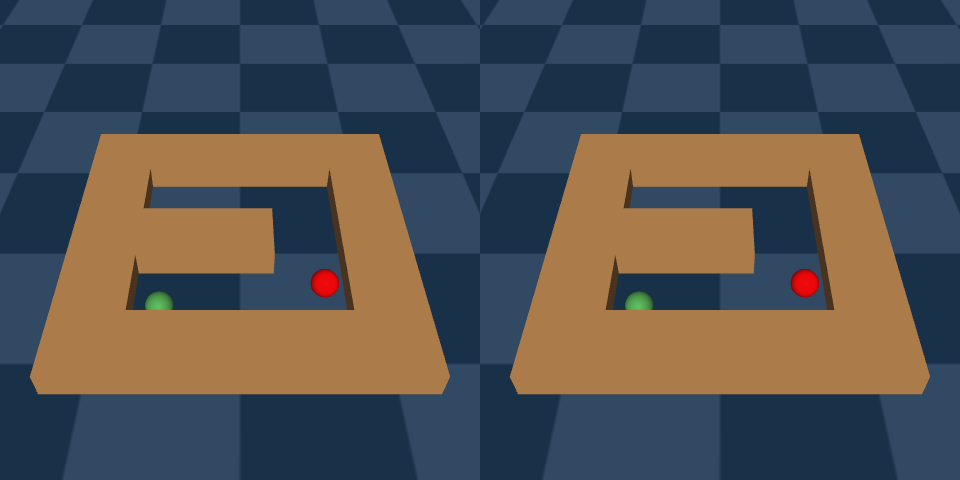

In [26]:
def _run_episode_rgb_traj(policy_fn, obs_window, env_id="PointMaze_UMaze-v3", max_steps=300, seed=42):
    import gymnasium_robotics  # noqa: F401  # register PointMaze envs
    env = gym.make(env_id, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)
    s = _extract_state(obs)
    obs_hist = collections.deque([s.copy() for _ in range(obs_window)], maxlen=obs_window)

    frames, ep_return, is_success = [], 0.0, False

    first = env.render()
    if first is not None:
        frames.append(first)

    for _ in range(max_steps):
        action = np.clip(np.asarray(policy_fn(np.stack(obs_hist, axis=0)), dtype=np.float32), -1.0, 1.0)
        obs, reward, terminated, truncated, info = env.step(action)
        s = _extract_state(obs)
        obs_hist.append(s.copy())
        ep_return += float(reward)
        if _is_success(info, terminated):
            is_success = True

        frame = env.render()
        if frame is not None:
            frames.append(frame)

        if terminated or truncated:
            break

    env.close()
    return frames, ep_return, is_success, env_id


print('Recording PointMaze episodes for GIF (official env render)…')
target_env = "PointMaze_UMaze-v3"
liq_frames, liq_ret, liq_succ, env_id_l = _run_episode_rgb_traj(liquid_pointmaze_action, obs_window=PM_OBS_WINDOW, env_id=target_env, seed=7)
diff_frames, diff_ret, diff_succ, env_id_d = _run_episode_rgb_traj(diffusion_pointmaze_action, obs_window=PM_OBS_WINDOW, env_id=target_env, seed=7)

max_len = max(len(liq_frames), len(diff_frames))
liq_frames += [liq_frames[-1]] * (max_len - len(liq_frames))
diff_frames += [diff_frames[-1]] * (max_len - len(diff_frames))

frames = []
for i in range(0, max_len, 3):
    lf = liq_frames[i]
    df = diff_frames[i]
    # Make heights match before concat
    h = min(lf.shape[0], df.shape[0])
    lf = lf[:h]
    df = df[:h]
    frames.append(np.concatenate([lf, df], axis=1))

gif_path = Path('artifacts') / 'pointmaze_umaze_v3_comparison_from_disk.gif'
gif_path.parent.mkdir(parents=True, exist_ok=True)
imageio.mimsave(gif_path, frames, fps=8, loop=0)
print(f'Env used (Liquid): {env_id_l}')
print(f'Env used (Diffusion): {env_id_d}')
print(f'Liquid return={liq_ret:.3f}, success={liq_succ}')
print(f'Diffusion return={diff_ret:.3f}, success={diff_succ}')
print(f'Saved {gif_path} ({len(frames)} frames @ 8 fps)')
display(Image(filename=str(gif_path)))

In [ ]:
# Multi-seed comparison on UMaze-v3 (v2-trained checkpoints)
import gymnasium_robotics  # noqa: F401

MULTISEED_ENV_ID = "PointMaze_UMaze-v3"
MULTISEED_TRIALS = 50
EPISODES_PER_TRIAL = 20
MAX_STEPS = 300

def evaluate_policy_seeded(
    policy_fn,
    env,
    seed_base,
    num_episodes=20,
    max_steps=300,
    obs_window=2,
    action_scale=1.0,
    distance_success_threshold=0.20,
):
    successes = 0
    distance_successes = 0
    returns = []
    final_goal_dists = []
    min_goal_dists = []
    total_infer_time = 0.0
    total_steps = 0

    for ep in range(num_episodes):
        obs, info = env.reset(seed=int(seed_base + ep))
        s = _extract_state(obs)
        obs_hist = collections.deque([s.copy() for _ in range(obs_window)], maxlen=obs_window)

        ep_return = 0.0
        ep_success = False
        ep_min_dist = _goal_distance_from_state(s)

        for _ in range(max_steps):
            hist_np = np.stack(obs_hist, axis=0)
            t0 = time.time()
            action = policy_fn(hist_np)
            total_infer_time += (time.time() - t0)

            action = np.clip(np.asarray(action, dtype=np.float32) * action_scale, -1.0, 1.0)
            obs, reward, terminated, truncated, info = env.step(action)
            s = _extract_state(obs)
            obs_hist.append(s.copy())

            d = _goal_distance_from_state(s)
            if np.isfinite(d):
                ep_min_dist = min(ep_min_dist, d)

            ep_return += float(reward)
            total_steps += 1
            ep_success = ep_success or _is_success(info, terminated)
            if terminated or truncated:
                break

        final_dist = _goal_distance_from_state(s)
        final_goal_dists.append(final_dist)
        min_goal_dists.append(ep_min_dist)
        is_distance_success = np.isfinite(ep_min_dist) and (ep_min_dist <= distance_success_threshold)

        distance_successes += int(is_distance_success)
        successes += int(ep_success)
        returns.append(ep_return)

    return {
        "success_rate": 100.0 * successes / max(1, num_episodes),
        "distance_success_rate": 100.0 * distance_successes / max(1, num_episodes),
        "avg_return": float(np.mean(returns)) if returns else 0.0,
        "avg_final_goal_dist": float(np.nanmean(final_goal_dists)) if final_goal_dists else float("nan"),
        "avg_min_goal_dist": float(np.nanmean(min_goal_dists)) if min_goal_dists else float("nan"),
        "avg_step_time_ms": (1000.0 * total_infer_time / max(1, total_steps)),
    }


def run_multiseed_policy(policy_fn, policy_name, trials=50):
    rows = []
    for t in tqdm(range(trials), desc=f"{policy_name} multiseed"):
        env = gym.make(MULTISEED_ENV_ID)
        # Separate env and policy randomness per trial
        seed_base = 1000 + 1000 * t
        np.random.seed(5000 + t)
        torch.manual_seed(7000 + t)
        res = evaluate_policy_seeded(
            policy_fn,
            env,
            seed_base=seed_base,
            num_episodes=EPISODES_PER_TRIAL,
            max_steps=MAX_STEPS,
            obs_window=PM_OBS_WINDOW,
            distance_success_threshold=0.20,
        )
        env.close()
        rows.append(res)
    return rows


def summarize_rows(rows):
    keys = [
        "success_rate",
        "distance_success_rate",
        "avg_return",
        "avg_final_goal_dist",
        "avg_min_goal_dist",
        "avg_step_time_ms",
    ]
    summary = {}
    for k in keys:
        vals = np.array([r[k] for r in rows], dtype=np.float64)
        summary[k + "_mean"] = float(np.mean(vals))
        summary[k + "_std"] = float(np.std(vals))
    return summary


liquid_rows = run_multiseed_policy(liquid_pointmaze_action, "Liquid", trials=MULTISEED_TRIALS)
diffusion_rows = run_multiseed_policy(diffusion_pointmaze_action, "Diffusion", trials=MULTISEED_TRIALS)

liq_sum = summarize_rows(liquid_rows)
diff_sum = summarize_rows(diffusion_rows)

print("\n" + "=" * 72)
print(f"MULTI-SEED POINTMAZE RESULTS ({MULTISEED_ENV_ID})")
print(f"Trials={MULTISEED_TRIALS}, Episodes/Trial={EPISODES_PER_TRIAL}, MaxSteps={MAX_STEPS}")
print("(mean ± std across trials)")
print("=" * 72)

def _pm(name, lmean, lstd, dmean, dstd, fmt=".2f"):
    print(f"{name:<26}  Liquid {format(lmean, fmt)} ± {format(lstd, fmt)}    Diffusion {format(dmean, fmt)} ± {format(dstd, fmt)}")

_pm("Success rate (%)", liq_sum['success_rate_mean'], liq_sum['success_rate_std'], diff_sum['success_rate_mean'], diff_sum['success_rate_std'])
_pm("Distance success (%)", liq_sum['distance_success_rate_mean'], liq_sum['distance_success_rate_std'], diff_sum['distance_success_rate_mean'], diff_sum['distance_success_rate_std'])
_pm("Avg return", liq_sum['avg_return_mean'], liq_sum['avg_return_std'], diff_sum['avg_return_mean'], diff_sum['avg_return_std'], fmt=".3f")
_pm("Avg final goal dist", liq_sum['avg_final_goal_dist_mean'], liq_sum['avg_final_goal_dist_std'], diff_sum['avg_final_goal_dist_mean'], diff_sum['avg_final_goal_dist_std'], fmt=".3f")
_pm("Avg min goal dist", liq_sum['avg_min_goal_dist_mean'], liq_sum['avg_min_goal_dist_std'], diff_sum['avg_min_goal_dist_mean'], diff_sum['avg_min_goal_dist_std'], fmt=".3f")
_pm("Step time (ms)", liq_sum['avg_step_time_ms_mean'], liq_sum['avg_step_time_ms_std'], diff_sum['avg_step_time_ms_mean'], diff_sum['avg_step_time_ms_std'], fmt=".3f")

Diffusion multiseed: 100%|██████████| 10/10 [00:42<00:00,  4.26s/it]


MULTI-SEED POINTMAZE RESULTS (PointMaze_UMaze-v3)
Trials=10, Episodes/Trial=20, MaxSteps=300
(mean ± std across trials)
Success rate (%)            Liquid 18.50 ± 8.38    Diffusion 12.50 ± 9.81
Distance success (%)        Liquid 8.50 ± 6.34    Diffusion 4.50 ± 4.15
Avg return                  Liquid 7.500 ± 4.771    Diffusion 9.805 ± 7.418
Avg final goal dist         Liquid 2.128 ± 0.100    Diffusion 2.064 ± 0.111
Avg min goal dist           Liquid 1.275 ± 0.119    Diffusion 1.510 ± 0.165
Step time (ms)              Liquid 1.230 ± 0.082    Diffusion 0.666 ± 0.042


## Sample-Efficiency Closed-Loop Runner (PointMaze)

This section reads `artifacts/sample_efficiency_training_manifest.json` (written by `01_training.ipynb`), loads each PointMaze checkpoint pair, evaluates them on official `PointMaze_UMaze-v3` with multi-seed rollouts, and writes closed-loop artifacts for `03_analysis.ipynb`.

Paper-aligned interpretation: this is the deployment-side robustness check corresponding to the offline sample-efficiency curves.

In [27]:
import json

SAMPLE_EFF_MANIFEST_PATH = Path("artifacts") / "sample_efficiency_training_manifest.json"
SAMPLE_EFF_PM_OUT_PATH = Path("artifacts") / "sample_efficiency_pointmaze_closedloop.json"

SAMPLE_EFF_PM_ENV_ID = "PointMaze_UMaze-v3"
SAMPLE_EFF_EVAL_TRIALS = 20   # set to 50 for final paper-quality estimate
SAMPLE_EFF_EVAL_EPISODES = 20
SAMPLE_EFF_EVAL_MAX_STEPS = 300
SAMPLE_EFF_DISTANCE_THRESH = 0.20


def _load_checkpoint_pair_into_adapters(liquid_ckpt_path: str, diffusion_ckpt_path: str):
    global liquid_pm_state, diffusion_pm_state
    global liq_state_proj_w, liq_state_proj_b, liq_context_proj_w, liq_context_proj_b
    global liq_head_context_w, liq_head_context_b, liq_mdn_logits_w, liq_mdn_logits_b, liq_mdn_mu_w, liq_mdn_mu_b
    global diff_state_proj_w, diff_state_proj_b, diff_context_proj_w, diff_context_proj_b
    global diff_head_context_w, diff_head_context_b, diff_mdn_logits_w, diff_mdn_logits_b, diff_mdn_mu_w, diff_mdn_mu_b

    liquid_pm_state = torch.load(liquid_ckpt_path, map_location=pm_device, weights_only=False)
    diffusion_pm_state = torch.load(diffusion_ckpt_path, map_location=pm_device, weights_only=False)

    liq_state_proj_w = liquid_pm_state["backbone.state_proj.weight"]
    liq_state_proj_b = liquid_pm_state["backbone.state_proj.bias"]
    liq_context_proj_w = liquid_pm_state["backbone.context_proj.weight"]
    liq_context_proj_b = liquid_pm_state["backbone.context_proj.bias"]
    liq_head_context_w = liquid_pm_state["context_proj.weight"]
    liq_head_context_b = liquid_pm_state["context_proj.bias"]
    liq_mdn_logits_w = liquid_pm_state["mdn_logits.weight"]
    liq_mdn_logits_b = liquid_pm_state["mdn_logits.bias"]
    liq_mdn_mu_w = liquid_pm_state["mdn_mu.weight"]
    liq_mdn_mu_b = liquid_pm_state["mdn_mu.bias"]

    diff_state_proj_w = diffusion_pm_state["backbone.state_proj.weight"]
    diff_state_proj_b = diffusion_pm_state["backbone.state_proj.bias"]
    diff_context_proj_w = diffusion_pm_state["backbone.context_proj.weight"]
    diff_context_proj_b = diffusion_pm_state["backbone.context_proj.bias"]
    diff_head_context_w = diffusion_pm_state["context_proj.weight"]
    diff_head_context_b = diffusion_pm_state["context_proj.bias"]
    diff_mdn_logits_w = diffusion_pm_state["mdn_logits.weight"]
    diff_mdn_logits_b = diffusion_pm_state["mdn_logits.bias"]
    diff_mdn_mu_w = diffusion_pm_state["mdn_mu.weight"]
    diff_mdn_mu_b = diffusion_pm_state["mdn_mu.bias"]


def _evaluate_policy_seeded_sampleeff(policy_fn, env, seed_base):
    successes = 0
    distance_successes = 0
    returns = []
    final_goal_dists = []
    min_goal_dists = []
    total_infer_time = 0.0
    total_steps = 0

    for ep in range(SAMPLE_EFF_EVAL_EPISODES):
        obs, info = env.reset(seed=int(seed_base + ep))
        s = _extract_state(obs)
        obs_hist = collections.deque([s.copy() for _ in range(PM_OBS_WINDOW)], maxlen=PM_OBS_WINDOW)

        ep_return = 0.0
        ep_success = False
        ep_min_dist = _goal_distance_from_state(s)

        for _ in range(SAMPLE_EFF_EVAL_MAX_STEPS):
            hist_np = np.stack(obs_hist, axis=0)
            t0 = time.time()
            action = policy_fn(hist_np)
            total_infer_time += (time.time() - t0)

            action = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
            obs, reward, terminated, truncated, info = env.step(action)
            s = _extract_state(obs)
            obs_hist.append(s.copy())

            d = _goal_distance_from_state(s)
            if np.isfinite(d):
                ep_min_dist = min(ep_min_dist, d)

            ep_return += float(reward)
            total_steps += 1
            ep_success = ep_success or _is_success(info, terminated)
            if terminated or truncated:
                break

        final_dist = _goal_distance_from_state(s)
        final_goal_dists.append(final_dist)
        min_goal_dists.append(ep_min_dist)
        is_distance_success = np.isfinite(ep_min_dist) and (ep_min_dist <= SAMPLE_EFF_DISTANCE_THRESH)

        distance_successes += int(is_distance_success)
        successes += int(ep_success)
        returns.append(ep_return)

    return {
        "success_rate": 100.0 * successes / max(1, SAMPLE_EFF_EVAL_EPISODES),
        "distance_success_rate": 100.0 * distance_successes / max(1, SAMPLE_EFF_EVAL_EPISODES),
        "avg_return": float(np.mean(returns)) if returns else 0.0,
        "avg_final_goal_dist": float(np.nanmean(final_goal_dists)) if final_goal_dists else float("nan"),
        "avg_min_goal_dist": float(np.nanmean(min_goal_dists)) if min_goal_dists else float("nan"),
        "avg_step_time_ms": (1000.0 * total_infer_time / max(1, total_steps)),
    }


def _summarize_trials(rows):
    keys = [
        "success_rate",
        "distance_success_rate",
        "avg_return",
        "avg_final_goal_dist",
        "avg_min_goal_dist",
        "avg_step_time_ms",
    ]
    out = {}
    for k in keys:
        vals = np.array([r[k] for r in rows], dtype=np.float64)
        out[k + "_mean"] = float(np.mean(vals))
        out[k + "_std"] = float(np.std(vals))
    return out


def run_pointmaze_sampleeff_closedloop(manifest_path=SAMPLE_EFF_MANIFEST_PATH):
    if not Path(manifest_path).exists():
        raise FileNotFoundError(f"Missing training manifest: {manifest_path}")

    with open(manifest_path, "r") as f:
        manifest = json.load(f)

    rows = manifest.get("rows", [])
    pm_rows = [r for r in rows if r.get("task") == "pointmaze"]
    if len(pm_rows) == 0:
        raise ValueError("No pointmaze rows found in training manifest.")

    results = []
    for row in sorted(pm_rows, key=lambda r: float(r["fraction"])):
        frac = float(row["fraction"])
        liq_ckpt = row["liquid_checkpoint"]
        diff_ckpt = row["diffusion_checkpoint"]

        if (not Path(liq_ckpt).exists()) or (not Path(diff_ckpt).exists()):
            print(f"Skipping fraction={frac:.2%}: missing checkpoints")
            continue

        print("\n" + "=" * 80)
        print(f"PointMaze sample-eff closed-loop eval | fraction={frac:.2%}")
        print("=" * 80)

        _load_checkpoint_pair_into_adapters(liq_ckpt, diff_ckpt)

        liq_trials, diff_trials = [], []
        for t in tqdm(range(SAMPLE_EFF_EVAL_TRIALS), desc=f"f={frac:.2%} multiseed"):
            env_l = gym.make(SAMPLE_EFF_PM_ENV_ID)
            env_d = gym.make(SAMPLE_EFF_PM_ENV_ID)
            seed_base = 1000 + 1000 * t
            np.random.seed(5000 + t)
            torch.manual_seed(7000 + t)
            liq_trials.append(_evaluate_policy_seeded_sampleeff(liquid_pointmaze_action, env_l, seed_base=seed_base))
            diff_trials.append(_evaluate_policy_seeded_sampleeff(diffusion_pointmaze_action, env_d, seed_base=seed_base))
            env_l.close()
            env_d.close()

        liq_sum = _summarize_trials(liq_trials)
        diff_sum = _summarize_trials(diff_trials)

        results.append({
            "task": "pointmaze",
            "env_id": SAMPLE_EFF_PM_ENV_ID,
            "fraction": frac,
            "fraction_pct": int(round(frac * 100)),
            "tag": row.get("tag", ""),
            "liquid_checkpoint": liq_ckpt,
            "diffusion_checkpoint": diff_ckpt,
            "liquid": liq_sum,
            "diffusion": diff_sum,
            "trials": int(SAMPLE_EFF_EVAL_TRIALS),
            "episodes_per_trial": int(SAMPLE_EFF_EVAL_EPISODES),
            "max_steps": int(SAMPLE_EFF_EVAL_MAX_STEPS),
            "distance_success_threshold": float(SAMPLE_EFF_DISTANCE_THRESH),
        })

        print(
            f"  Liquid success={liq_sum['success_rate_mean']:.2f}±{liq_sum['success_rate_std']:.2f} | "
            f"Diffusion success={diff_sum['success_rate_mean']:.2f}±{diff_sum['success_rate_std']:.2f}"
        )

    payload = {
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "env_id": SAMPLE_EFF_PM_ENV_ID,
        "results": results,
    }
    with open(SAMPLE_EFF_PM_OUT_PATH, "w") as f:
        json.dump(payload, f, indent=2)

    print("\n✓ Saved PointMaze closed-loop sample-efficiency results")
    print(f"  {SAMPLE_EFF_PM_OUT_PATH}")
    return payload


print("PointMaze sample-efficiency closed-loop runner ready.")
print("Run:")
print("  run_pointmaze_sampleeff_closedloop()")

PointMaze sample-efficiency closed-loop runner ready.
Run:
  run_pointmaze_sampleeff_closedloop()


In [ ]:
# ── Direct fraction-checkpoint evaluation (bypasses stale manifest) ──────────
#   Loads each sampleeff checkpoint pair directly and writes fresh results.

FRAC_TAGS_PM = {
    'f00100bp': 0.01,
    'f00215bp': 0.021544,
    'f00464bp': 0.046416,
    'f01000bp': 0.100,
    'f02154bp': 0.215443,
    'f04642bp': 0.464159,
    'f10000bp': 1.0,
}
SEED = 'seed7'
PM_SAMPLEEFF_EVAL_TRIALS    = 20   # 20 trials × 20 eps = 400 episodes per fraction
PM_SAMPLEEFF_EVAL_EPISODES  = 20
PM_SAMPLEEFF_MAX_STEPS      = 300
PM_SAMPLEEFF_DIST_THRESH    = 0.20
PM_SAMPLEEFF_OUT_PATH       = Path('artifacts') / 'sample_efficiency_pointmaze_closedloop.json'


def run_pm_sampleeff_direct(dry_run=False):
    """Evaluate all fraction checkpoints in FRAC_TAGS_PM directly."""
    results = []

    items = list(sorted(FRAC_TAGS_PM.items(), key=lambda x: x[1]))
    if dry_run:
        # Quick smoke-test: 1 trial, 5 episodes, only 1% fraction
        items = items[:1]
        n_trials, n_eps = 1, 5
    else:
        n_trials, n_eps = PM_SAMPLEEFF_EVAL_TRIALS, PM_SAMPLEEFF_EVAL_EPISODES

    for frac_tag, frac_val in items:
        liq_ckpt  = f'checkpoints/liquid_jepa_pointmaze_umaze_sampleeff_{frac_tag}_{SEED}_best.pt'
        diff_ckpt = f'checkpoints/diffusion_jepa_pointmaze_umaze_sampleeff_{frac_tag}_{SEED}_best.pt'

        if not Path(liq_ckpt).exists() or not Path(diff_ckpt).exists():
            print(f'  SKIP {frac_tag}: missing checkpoints')
            continue

        print(f'\n{"="*72}')
        print(f'fraction={frac_val*100:.2f}%  ({frac_tag})')
        print(f'  liquid:    {liq_ckpt}')
        print(f'  diffusion: {diff_ckpt}')
        print(f'{"="*72}')

        _load_checkpoint_pair_into_adapters(liq_ckpt, diff_ckpt)

        liq_trials_r, diff_trials_r = [], []
        for t in tqdm(range(n_trials), desc=f'{frac_tag} trials'):
            seed_base = 1000 + 1000 * t
            np.random.seed(5000 + t)
            torch.manual_seed(7000 + t)

            env_l = gym.make('PointMaze_UMaze-v3')
            env_d = gym.make('PointMaze_UMaze-v3')

            # reuse _evaluate_policy_seeded_sampleeff from the existing runner
            # (temporarily patch globals)
            old_trials, old_eps, old_steps, old_thresh = (
                SAMPLE_EFF_EVAL_TRIALS, SAMPLE_EFF_EVAL_EPISODES,
                SAMPLE_EFF_EVAL_MAX_STEPS, SAMPLE_EFF_DISTANCE_THRESH,
            )
            import builtins
            # call directly with overridden params via local helper
            def _eval_ep(policy_fn, env, sb):
                successes = 0; distance_successes = 0
                returns = []; final_dists = []; min_dists = []
                infer_t = 0.0; total_s = 0
                for ep in range(n_eps):
                    obs, info = env.reset(seed=int(sb + ep))
                    s = _extract_state(obs)
                    obs_hist = collections.deque([s.copy() for _ in range(PM_OBS_WINDOW)], maxlen=PM_OBS_WINDOW)
                    ep_ret = 0.0; ep_ok = False
                    ep_min = _goal_distance_from_state(s)
                    for _ in range(PM_SAMPLEEFF_MAX_STEPS):
                        hist_np = np.stack(obs_hist, axis=0)
                        t0 = time.time(); action = policy_fn(hist_np); infer_t += time.time() - t0
                        action = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
                        obs, rew, term, trunc, info = env.step(action)
                        s = _extract_state(obs); obs_hist.append(s.copy())
                        d = _goal_distance_from_state(s)
                        if np.isfinite(d): ep_min = min(ep_min, d)
                        ep_ret += float(rew); total_s += 1
                        ep_ok = ep_ok or _is_success(info, term)
                        if term or trunc: break
                    fd = _goal_distance_from_state(s)
                    final_dists.append(fd); min_dists.append(ep_min)
                    successes += int(ep_ok)
                    distance_successes += int(np.isfinite(ep_min) and ep_min <= PM_SAMPLEEFF_DIST_THRESH)
                    returns.append(ep_ret)
                return {
                    'success_rate':          100.0 * successes / max(1, n_eps),
                    'distance_success_rate': 100.0 * distance_successes / max(1, n_eps),
                    'avg_return':            float(np.mean(returns)),
                    'avg_final_goal_dist':   float(np.nanmean(final_dists)),
                    'avg_min_goal_dist':     float(np.nanmean(min_dists)),
                    'avg_step_time_ms':      1000.0 * infer_t / max(1, total_s),
                }

            liq_trials_r.append(_eval_ep(liquid_pointmaze_action, env_l, seed_base))
            diff_trials_r.append(_eval_ep(diffusion_pointmaze_action, env_d, seed_base))
            env_l.close(); env_d.close()

        def _summ(rows):
            keys = ['success_rate','distance_success_rate','avg_return',
                    'avg_final_goal_dist','avg_min_goal_dist','avg_step_time_ms']
            out = {}
            for k in keys:
                vals = np.array([r[k] for r in rows])
                out[k+'_mean'] = float(np.mean(vals))
                out[k+'_std']  = float(np.std(vals))
            return out

        ls, ds = _summ(liq_trials_r), _summ(diff_trials_r)
        print(f'  Liquid   success={ls["success_rate_mean"]:.1f}±{ls["success_rate_std"]:.1f}%  '
              f'dist_success={ls["distance_success_rate_mean"]:.1f}%')
        print(f'  Diffusion success={ds["success_rate_mean"]:.1f}±{ds["success_rate_std"]:.1f}%  '
              f'dist_success={ds["distance_success_rate_mean"]:.1f}%')

        results.append({
            'task':                      'pointmaze',
            'env_id':                    'PointMaze_UMaze-v3',
            'fraction':                  frac_val,
            'frac_tag':                  frac_tag,
            'liquid_checkpoint':         liq_ckpt,
            'diffusion_checkpoint':      diff_ckpt,
            'liquid':                    ls,
            'diffusion':                 ds,
            'trials':                    n_trials,
            'episodes_per_trial':        n_eps,
            'max_steps':                 PM_SAMPLEEFF_MAX_STEPS,
            'distance_success_threshold':PM_SAMPLEEFF_DIST_THRESH,
        })

    payload = {
        'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
        'env_id':     'PointMaze_UMaze-v3',
        'results':    results,
    }
    with open(PM_SAMPLEEFF_OUT_PATH, 'w') as f:
        json.dump(payload, f, indent=2)

    print(f'\n✓ Saved {len(results)} fraction results → {PM_SAMPLEEFF_OUT_PATH}')
    return payload


print('run_pm_sampleeff_direct() ready.')
print('  dry_run=True  → 1 fraction, 1 trial, 5 episodes  (~30 s)')
print('  dry_run=False → all fractions, 20 trials, 20 eps  (~30 min)')


## 6. Alt-Seed Robustness Sweep

Runs the same 7-fraction evaluation using a **second independent seed family** (base offset 200 000) to confirm results aren't artifacts of the original seed sequence.

- 20 trials × 20 episodes per fraction (~30 min total)  
- Output → `artifacts/sample_efficiency_pointmaze_closedloop_extra20_altseed.json`  
- The cell is **idempotent**: re-running when the output file already exists is a no-op.

In [ ]:
import json as _json

ALT_N_TRIALS     = 20
ALT_N_EPISODES   = 20
ALT_MAX_STEPS    = 300
ALT_DIST_THRESH  = 0.20
ALT_ENV_ID       = "PointMaze_UMaze-v3"
ALT_SEED_OFFSET  = 200_000
ALT_OUT_PATH     = Path("artifacts") / "sample_efficiency_pointmaze_closedloop_extra20_altseed.json"


def run_altseed_sweep(frac_tags=None):
    """Evaluate all FRAC_TAGS_PM fractions with an alternate seed family (offset 200k)."""
    import time as _time
    if frac_tags is None:
        frac_tags = FRAC_TAGS_PM
    results = []

    for frac_tag, frac in sorted(frac_tags.items(), key=lambda x: x[1]):
        liq_ckpt  = Path("checkpoints") / f"liquid_jepa_pointmaze_umaze_sampleeff_{frac_tag}_{SEED}_best.pt"
        diff_ckpt = Path("checkpoints") / f"diffusion_jepa_pointmaze_umaze_sampleeff_{frac_tag}_{SEED}_best.pt"

        print(f"\n{'='*72}")
        print(f"ALT seed sweep | fraction={frac:.2%}  ({frac_tag})")
        if not liq_ckpt.exists() or not diff_ckpt.exists():
            print("  [SKIP] Missing checkpoint(s)")
            continue

        _load_checkpoint_pair_into_adapters(str(liq_ckpt), str(diff_ckpt))

        liq_trials, diff_trials = [], []
        for t in tqdm(range(ALT_N_TRIALS), desc=f"{frac_tag} alt"):
            seed_base = ALT_SEED_OFFSET + 1000 * t
            np.random.seed(ALT_SEED_OFFSET + 5000 + t)
            torch.manual_seed(ALT_SEED_OFFSET + 7000 + t)
            env_l = gym.make(ALT_ENV_ID)
            env_d = gym.make(ALT_ENV_ID)
            liq_trials.append(_evaluate_policy_seeded_sampleeff(liquid_pointmaze_action, env_l, seed_base))
            diff_trials.append(_evaluate_policy_seeded_sampleeff(diffusion_pointmaze_action, env_d, seed_base))
            env_l.close(); env_d.close()

        ls, ds = _summarize_trials(liq_trials), _summarize_trials(diff_trials)
        print(f"  Liquid={ls['success_rate_mean']:.1f}±{ls['success_rate_std']:.1f}%  "
              f"Diffusion={ds['success_rate_mean']:.1f}±{ds['success_rate_std']:.1f}%")

        results.append({
            "task": "pointmaze", "env_id": ALT_ENV_ID,
            "fraction": float(frac), "frac_tag": frac_tag,
            "seed_family": f"alt_offset_{ALT_SEED_OFFSET}",
            "liquid_checkpoint": str(liq_ckpt), "diffusion_checkpoint": str(diff_ckpt),
            "liquid": ls, "diffusion": ds,
            "trials": ALT_N_TRIALS, "episodes_per_trial": ALT_N_EPISODES,
            "max_steps": ALT_MAX_STEPS, "distance_success_threshold": ALT_DIST_THRESH,
        })

    payload = {
        "created_at": _time.strftime("%Y-%m-%d %H:%M:%S"),
        "env_id": ALT_ENV_ID,
        "seed_family": f"alt_offset_{ALT_SEED_OFFSET}",
        "results": results,
    }
    with open(ALT_OUT_PATH, "w") as f:
        _json.dump(payload, f, indent=2)
    print(f"\n✓ Saved alt-seed results → {ALT_OUT_PATH}")
    return payload


if ALT_OUT_PATH.exists():
    print(f"Alt-seed results already exist: {ALT_OUT_PATH}")
    print("Delete the file and re-run this cell to regenerate.")
else:
    run_altseed_sweep()

## 7. Pool Seed Families

Combines the original (seed 1000+) and alt-seed (seed 200 000+) results into a single JSON using the exact pooled-variance formula.  
Output → `artifacts/sample_efficiency_pointmaze_closedloop_pooled.json` (40 trials per fraction)  
This is the file consumed by `03_analysis.ipynb` for Figure 5.

In [ ]:
import math as _math
import json as _json
from datetime import datetime as _dt

ORIG_PATH = Path("artifacts") / "sample_efficiency_pointmaze_closedloop.json"
ALT_PATH  = Path("artifacts") / "sample_efficiency_pointmaze_closedloop_extra20_altseed.json"
POOL_PATH = Path("artifacts") / "sample_efficiency_pointmaze_closedloop_pooled.json"


def _pool_stats(m1, s1, n1, m2, s2, n2):
    """Exact pooled mean and standard deviation from two groups."""
    n = n1 + n2
    mean = (n1 * m1 + n2 * m2) / n
    var  = (n1 * (s1 ** 2 + (m1 - mean) ** 2) + n2 * (s2 ** 2 + (m2 - mean) ** 2)) / n
    return mean, _math.sqrt(var)


def _pool_model(r1, r2, key, n1, n2):
    m1, m2 = r1[key], r2[key]
    out = {}
    for k in m1:
        if k.endswith("_mean"):
            base = k[:-5]
            mean, std = _pool_stats(m1[k], m1.get(base + "_std", 0), n1,
                                    m2[k], m2.get(base + "_std", 0), n2)
            out[base + "_mean"] = mean
            out[base + "_std"]  = std
    return out


def pool_seed_families(orig_path=ORIG_PATH, alt_path=ALT_PATH, out_path=POOL_PATH):
    orig    = _json.load(open(orig_path))
    alt     = _json.load(open(alt_path))
    alt_map = {r["fraction"]: r for r in alt["results"]}
    n1      = orig["results"][0]["trials"]
    n2      = alt["results"][0]["trials"]

    pooled = []
    for r1 in orig["results"]:
        r2 = alt_map.get(r1["fraction"])
        if r2 is None:
            pooled.append(r1)
            continue
        pooled.append({
            **{k: r1[k] for k in ["task", "env_id", "fraction", "frac_tag",
                                   "liquid_checkpoint", "diffusion_checkpoint",
                                   "episodes_per_trial", "max_steps",
                                   "distance_success_threshold"]},
            "liquid":        _pool_model(r1, r2, "liquid",    n1, n2),
            "diffusion":     _pool_model(r1, r2, "diffusion", n1, n2),
            "trials":        n1 + n2,
            "seed_families": ["original_1000", f"alt_offset_{ALT_SEED_OFFSET}"],
        })

    payload = {
        "created_at": _dt.now().strftime("%Y-%m-%d %H:%M:%S"),
        "env_id":     orig["env_id"],
        "note":       f"Pooled: original ({n1} trials) + alt-seed ({n2} trials) = {n1+n2} per fraction",
        "results":    pooled,
    }
    with open(out_path, "w") as f:
        _json.dump(payload, f, indent=2)

    print(f"✓ Pooled {len(pooled)} fractions ({n1}+{n2}={n1+n2} trials each) → {out_path}\n")
    print(f"{'Fraction':>10} | {'Liquid':>8} | {'Diffusion':>10} | Winner")
    print("-" * 46)
    for r in pooled:
        liq  = r["liquid"]["success_rate_mean"]
        diff = r["diffusion"]["success_rate_mean"]
        print(f"{r['fraction']*100:9.2f}% | {liq:6.1f}%   | {diff:6.1f}%     | "
              f"{'LIQUID' if liq > diff else 'DIFFUSION'}")
    return payload


if POOL_PATH.exists():
    print(f"Pooled results already exist: {POOL_PATH}")
    print("Delete and re-run to regenerate.")
else:
    pool_seed_families()